## Строим BASELINE model - линейную регрессию

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
from all_funcs import *
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
#загружаем датасет
df = pd.read_csv('podcasts.csv')

In [3]:
df.isna().sum()

Podcast_Name                      0
Episode_Title                     0
Episode_Length_minutes         5246
Genre                             0
Host_Popularity_percentage        0
Publication_Day                   0
Publication_Time                  0
Guest_Popularity_percentage    5258
Number_of_Ads                     0
Episode_Sentiment                 0
Listening_Time_minutes         5395
dtype: int64

In [4]:
df = df.dropna(subset=['Listening_Time_minutes', 'Guest_Popularity_percentage', 'Episode_Length_minutes'])

In [5]:
#собираем кат и кол-ые фичи
numeric_features_columns = df.select_dtypes(np.number).columns
cat_features_columns = df.select_dtypes(object).columns
target_column = 'Listening_Time_minutes'

In [6]:
# формируем тестовую и тренировочную выборки
X, y = df.drop(labels=['Listening_Time_minutes'], axis=1), df['Listening_Time_minutes']

#Создаем pipeline линейной регрессии с препроцессором фичей

model = make_pipeline_preprocessor_and_model(num_col=numeric_features_columns, cat_col=cat_features_columns, model_class=LinearRegression, scaler=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [7]:
#обучаем простую модель линейной регрессии
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
#предсказываем таргет
y_pred = model.predict(X_test)

#### Метрики качества на TEST и TRAIN выборке

In [9]:
show_all_regressor_metrics(y_pred=y_pred, y_test=y_test, title='TEST')
y_train_pred = model.predict(X_train)
show_all_regressor_metrics(y_pred=y_train_pred, y_test=y_train, title='TRAIN')


=============================TEST========================================
R2 - 0.8282145774386761
MSE - 127.37472481346389
RMSE - 11.28604114884683
=============================TRAIN========================================
R2 - 0.8279228057949215
MSE - 127.0967256129819
RMSE - 11.273718357888043


In [10]:
#датафрейм с результатами обучения моделей

models_result = {'model': [],
               'train_r2': [],
               'train_mse': [],
               'train_rmse': [],
               'test_r2': [],
               'test_mse': [],
               'test_rmse': []}
df_results_model = pd.DataFrame(models_result)

append_model_results(data=df_results_model, y_pred=y_pred, y_pred_train=y_train_pred, y_train=y_train, y_test=y_test, title='base_linear_model')


Среднее остатков: -0.0269 (должно быть близко к 0)


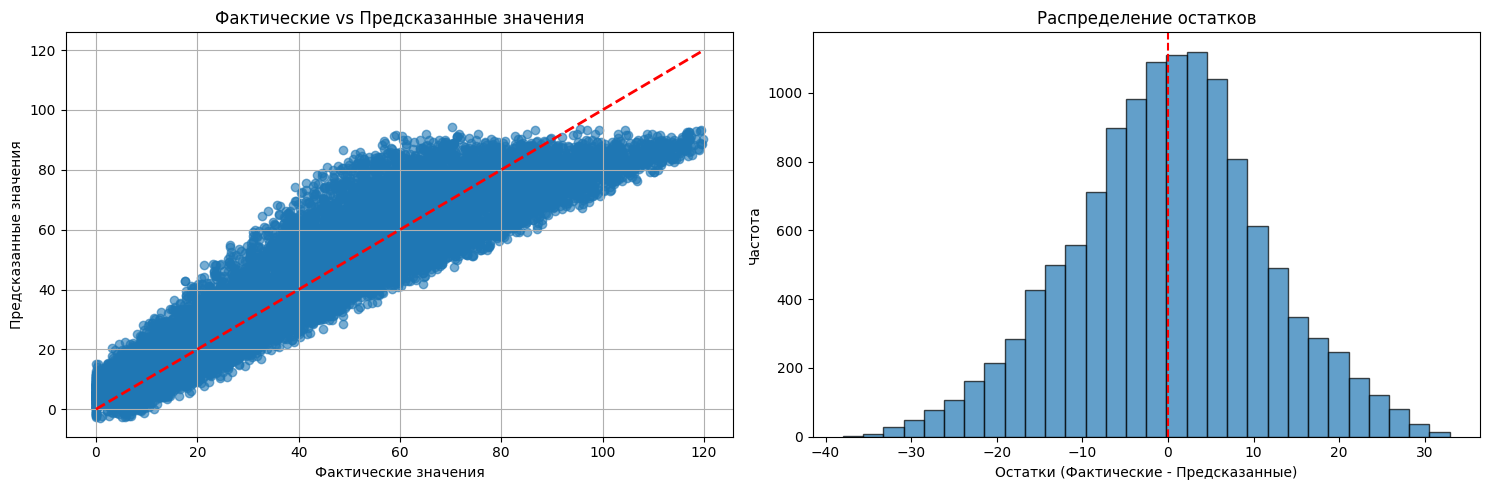

In [11]:
# Вычисляем остатки (ОПРЕДЕЛЯЕМ ПЕРЕМЕННУЮ residuals)
residuals = y_test - y_pred
print(f"\nСреднее остатков: {residuals.mean():.4f} (должно быть близко к 0)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Фактические vs Предсказанные значения
axes[0].scatter(y_test, y_pred, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title('Фактические vs Предсказанные значения')
axes[0].grid(True)

# 2. Распределение остатков
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Остатки (Фактические - Предсказанные)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков')

plt.tight_layout()
plt.show()

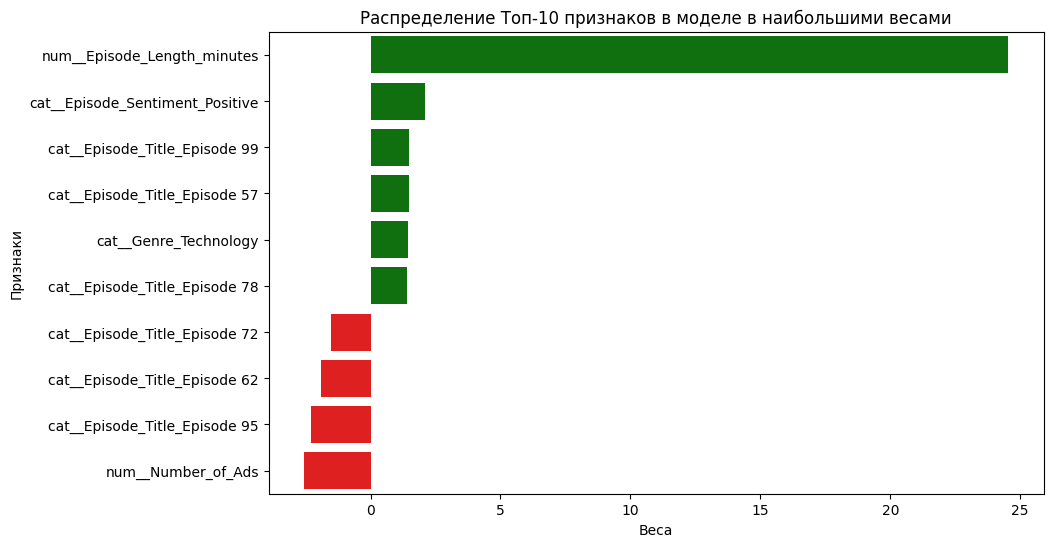

In [14]:
#Выведем наиболее важные признаки отобранные для предикта моделью
show_importance_feature_model(model=model, type_model='linear')

In [15]:
#записываем во внешний файл
import openpyxl
df_results_model.to_excel('models_results.xlsx', index=False)